# Real FFT — `fft.h`: verification & findings

The shared real FFT, measured. Like the other Tap notebooks, every cell drives the **actual
shipping DSP** — `tap::dsp::basic_real_fft<Sample, Scaling>` in all four profiles (double, float,
Q15, Q31; the fixed-point two under both scaling policies), the same header the consuming libraries
compile — through the C ABI in `tools/capi/` (`dsptap_fft_*`), loaded via ctypes
(`dsptap_py.RealFFT`). Nothing here is a Python re-implementation of the transform; the one
external reference is `numpy.fft.rfft`, used as the oracle for the packing and sign convention, and
the one model is Welch's fixed-point noise analysis, drawn against what the kernel measures.

Contents:

1. **Packing and sign convention** — the header's packed layout, and the conjugate relation to
   the engineering-convention DFT (`numpy.fft.rfft`), demonstrated bin for bin.
2. **Float vs double** — per-bin relative error of the float32 profile against the double golden
   model, as a function of N, on the profile's own arithmetic (no double round trip).
3. **Round trip** — `forward → inverse` reconstruction error vs N for both floating profiles.
4. **Fixed point (Stage 3b/3c)** — the Q15 and Q31 profiles under fixed scaling and block floating
   point: the exponent contract at the ABI boundary; the per-bin noise floor vs input level at
   0 / −20 / −40 / −60 dBFS for N = 256 / 512 / 2048 on white noise and an on-bin tone, against
   Welch's model and beside the battery's pinned numbers; the Q31 DC-path rounding bias followed
   past the battery's N = 2048 to N = 65536; the block-floating exponent on speech-like material;
   and the pinned output fingerprints reproduced through the ABI (host identity).
5. **Backend comparison (Stage 4) — placeholder.** What a same-binary Ooura-vs-vDSP/CMSIS
   comparison will measure once the engine is an explicit parameter.

The setup cell prints where the committed execution ran, the tree it measured (the pin SHA) and
which float32 backend the capi binary carried (Ooura on Linux and Windows, vDSP on macOS,
CMSIS-Helium on the M55); every figure carries the same stamp. The fixed-point kernel is the
portable int32 kernel on every host, so §4's numbers are host-independent by construction (§4.5
checks that against the battery's pins). This notebook is committed **executed**, per the house
rule (CLAUDE.md, *Verification layer*); re-execute with
`jupyter nbconvert --to notebook --execute --inplace notebooks/fft.ipynb` (environment:
`notebooks/requirements.txt`) after any change to `fft.h` or `fft/`.

In [1]:
import datetime
import pathlib
import platform
import subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import dsptap_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
rng = np.random.default_rng(20260917)

EPS32, EPS64 = np.finfo(np.float32).eps, np.finfo(np.float64).eps
SIZES = [2 ** k for k in range(3, 17)]   # 8 .. 65536

BACKEND = tap.RealFFT.backend()

def _git(*args):
    try:
        return subprocess.run(["git", *args], cwd=tap.ROOT, check=True, capture_output=True,
                              text=True).stdout.strip()
    except Exception:
        return "unknown"

def _compiler():
    # The compiler the capi binary was built with, from the standalone build's cache.
    try:
        cache = (tap.ROOT / "build_capi" / "CMakeCache.txt").read_text()
        cxx = next(l.split("=", 1)[1] for l in cache.splitlines() if l.startswith("CMAKE_CXX_COMPILER:"))
        return subprocess.run([cxx, "--version"], check=True, capture_output=True, text=True).stdout.splitlines()[0]
    except Exception:
        return "unknown compiler"

PIN_SHA = _git("rev-parse", "--short", "HEAD") + ("+dirty" if _git("status", "--porcelain", "--", "include", "tools") else "")
HOST = f"{platform.system()} {platform.machine()}"
TODAY = datetime.date.today().isoformat()
STAMP = f"DspTap {PIN_SHA} · {HOST} · {_compiler()} · float32 backend {BACKEND} · {TODAY}"

def stamp(fig, bottom=0.05):
    """Every figure names the tree it measured, the host and the date (the house rule for
    committed measurements); the layout leaves the bottom strip for it."""
    fig.tight_layout(rect=(0, bottom, 1, 0.96 if fig._suptitle is not None else 1))
    fig.text(0.99, 0.004, STAMP, ha="right", va="bottom", fontsize=6.5, color="0.45")

print(f"the committed execution ran on {HOST} "
      f"(Python {platform.python_version()}, numpy {np.__version__}, matplotlib {matplotlib.__version__}), "
      f"float32 backend {BACKEND!r}; the double profile is always Ooura, the fixed-point profiles the int32 kernel")
print(f"tree measured: {PIN_SHA} ({TODAY}); capi compiled by {_compiler()}")
for p in tap.RealFFT.PROFILES:
    f = tap.RealFFT(512, p)
    print(f"RealFFT(512, {p!r:10}): native dtype {str(f.dtype):8} num_bins {f.num_bins}  exponent bound {f.exponent_bound}")

the committed execution ran on Linux x86_64 (Python 3.11.15, numpy 2.4.6, matplotlib 3.11.2), float32 backend 'ooura'; the double profile is always Ooura, the fixed-point profiles the int32 kernel
tree measured: 2af3de6 (2026-09-23); capi compiled by c++ (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
RealFFT(512, 'double'  ): native dtype float64  num_bins 257  exponent bound 0
RealFFT(512, 'float'   ): native dtype float32  num_bins 257  exponent bound 0
RealFFT(512, 'q15'     ): native dtype int16    num_bins 257  exponent bound 9
RealFFT(512, 'q31'     ): native dtype int32    num_bins 257  exponent bound 10
RealFFT(512, 'q15_bfp' ): native dtype int16    num_bins 257  exponent bound 9
RealFFT(512, 'q31_bfp' ): native dtype int32    num_bins 257  exponent bound 10


## 1 · Packing and sign convention, against `numpy.fft.rfft`

`fft.h`'s contract for a forward transform of N real samples, packed into N reals:

- `data[0]` = DC (real), `data[1]` = Nyquist (real) — their imaginary parts are zero for a real
  signal and are not stored;
- `data[2k] + i·data[2k+1]` = bin k for 1 ≤ k < N/2;
- the kernel is W = exp(**+**2πi/N), so every imaginary part is **conjugated** relative to the
  engineering-convention DFT (exp(−2πi/N)) that `numpy.fft.rfft` computes.

`RealFFT.unpack` undoes the packing *and* conjugates, so it lands in numpy's convention; the
cell below checks all three points bin for bin, and shows the raw (un-conjugated) imaginary
parts mirroring numpy's.

DC:      packed[0] = +4.030030   rfft[0]      = +4.030030 (imag +0.0e+00)
Nyquist: packed[1] = -1.520776   rfft[N/2]    = -1.520776 (imag +0.0e+00)
max |packed_re - rfft_re|   over bins 1..N/2-1: 1.78e-15
max |packed_im - rfft_im|   (same sign):        3.01e+01   <- not equal
max |packed_im - (-rfft_im)| (conjugate):       2.44e-15   <- equal
max |unpack(forward(x)) - rfft(x)|: 2.68e-15
max |pack(unpack(X)) - X|:          0.00e+00


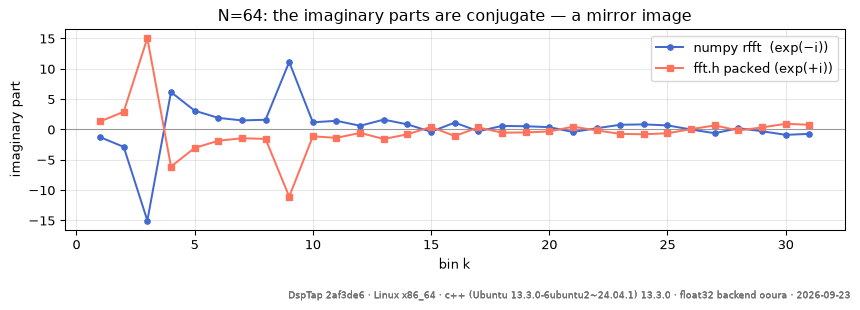

In [2]:
N = 64
n = np.arange(N)
x = np.sin(2 * np.pi * 3.3 * n / N) + 0.5 * np.cos(2 * np.pi * 9 * n / N + 0.7) + 0.1 * rng.standard_normal(N)

fft64 = tap.RealFFT(N, "double")
packed = fft64.forward(x)            # raw Ooura layout, exp(+i) convention
ref = np.fft.rfft(x)                 # engineering convention

# (a) DC and Nyquist sit at data[0] and data[1], real.
print(f"DC:      packed[0] = {packed[0]:+.6f}   rfft[0]      = {ref[0].real:+.6f} (imag {ref[0].imag:+.1e})")
print(f"Nyquist: packed[1] = {packed[1]:+.6f}   rfft[N/2]    = {ref[-1].real:+.6f} (imag {ref[-1].imag:+.1e})")

# (b) Interior bins: real parts agree, imaginary parts are NEGATED.
raw_im = packed[3::2]                # imag of bins 1..N/2-1, Ooura orientation
print(f"max |packed_re - rfft_re|   over bins 1..N/2-1: {np.max(np.abs(packed[2::2] - ref[1:-1].real)):.2e}")
print(f"max |packed_im - rfft_im|   (same sign):        {np.max(np.abs(raw_im - ref[1:-1].imag)):.2e}   <- not equal")
print(f"max |packed_im - (-rfft_im)| (conjugate):       {np.max(np.abs(raw_im + ref[1:-1].imag)):.2e}   <- equal")

# (c) unpack() lands in numpy's convention; pack() is its exact inverse.
print(f"max |unpack(forward(x)) - rfft(x)|: {np.max(np.abs(fft64.unpack(packed) - ref)):.2e}")
print(f"max |pack(unpack(X)) - X|:          {np.max(np.abs(fft64.pack(fft64.unpack(packed)) - packed)):.2e}")

k = np.arange(1, N // 2)
fig, ax = plt.subplots()
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(k, ref[1:-1].imag, "o-", color=C[0], ms=4, lw=1.5, label="numpy rfft  (exp(−i))")
ax.plot(k, raw_im, "s-", color=C[2], ms=4, lw=1.5, label="fft.h packed (exp(+i))")
ax.set(xlabel="bin k", ylabel="imaginary part", title=f"N={N}: the imaginary parts are conjugate — a mirror image")
ax.legend()
stamp(fig)
stamp(fig)
stamp(fig)
plt.show()

## 2 · Float vs double: per-bin relative error vs N

The float32 profile is the embedded profile; the double profile is the golden model. Here the
**same float32-representable input** goes through both — the double transform receives the
float32 values widened, so the comparison isolates the transform's arithmetic and not the input
rounding — and the float profile runs through `forward_inplace_raw` on a float32 buffer, i.e.
`basic_real_fft<float>::forward_inplace` with no conversion anywhere.

Input is white Gaussian noise (unit variance), so no bin is numerically empty and a per-bin
relative error is meaningful. Two statistics are plotted against N: the median and 95th
percentile of |X₃₂[k] − X₆₄[k]| / |X₆₄[k]|, and the whole-spectrum RMS error relative to the
spectrum's RMS — the number a noise-floor budget uses. The dotted guide grows as √log₂N,
anchored at the N = 64 measurement (N = 8 has five bins and is the noisiest point of the
sweep): for floating-point rounding the output noise-to-signal
*power* ratio grows in proportion to the number of stages ν = log₂N (Weinstein, "Roundoff noise
in floating point fast Fourier transform computation," *IEEE Trans. Audio Electroacoust.* 1969;
Oppenheim & Schafer ch. 9), so the RMS error grows as √ν. The worst-case bound ε₃₂·log₂N
(Gentleman & Sande 1966) is printed alongside for scale; the cell also fits the measured
exponent.

     N     median        p95        max    rms rel   (per-bin |X32-X64|/|X64|, white noise)
     8   4.26e-08   9.10e-07   1.12e-06   5.43e-08
    16   7.32e-08   2.29e-07   2.71e-07   6.87e-08
    32   7.70e-08   1.49e-07   2.56e-07   9.18e-08
    64   7.52e-08   2.72e-07   3.30e-07   1.02e-07
   128   1.07e-07   4.04e-07   4.01e-06   1.06e-07
   256   1.17e-07   3.93e-07   1.49e-06   1.17e-07
   512   1.02e-07   4.39e-07   1.27e-06   1.15e-07
  1024   1.20e-07   5.12e-07   9.28e-06   1.20e-07
  2048   1.21e-07   4.88e-07   1.87e-06   1.24e-07
  4096   1.38e-07   5.65e-07   3.98e-06   1.37e-07
  8192   1.39e-07   5.63e-07   1.06e-05   1.40e-07
 16384   1.45e-07   6.03e-07   7.09e-06   1.47e-07
 32768   1.47e-07   6.01e-07   3.08e-05   1.50e-07
 65536   1.53e-07   6.31e-07   4.70e-05   1.54e-07


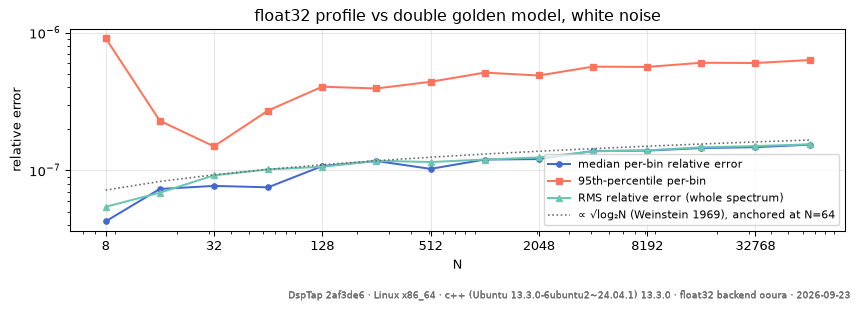

fitted RMS relative error ∝ (log₂N)^0.57   (√ν model predicts 0.50)
at N=65536: measured RMS 1.54e-07 vs worst-case bound ε₃₂·log₂N = 1.91e-06


In [3]:
def float_vs_double(N, x32):
    xd = x32.astype(np.float64)
    Xd = tap.RealFFT(N, "double").unpack(tap.RealFFT(N, "double").forward(xd))
    buf = x32.copy()
    tap.RealFFT(N, "float").forward_inplace_raw(buf)
    Xf = tap.RealFFT.unpack(buf.astype(np.float64))
    rel = np.abs(Xf - Xd) / np.abs(Xd)
    rms = np.linalg.norm(Xf - Xd) / np.linalg.norm(Xd)
    return np.median(rel), np.percentile(rel, 95), np.max(rel), rms

rows = []
for N in SIZES:
    x32 = rng.standard_normal(N).astype(np.float32)
    rows.append((N, *float_vs_double(N, x32)))
rows = np.array(rows)

print(f"{'N':>6} {'median':>10} {'p95':>10} {'max':>10} {'rms rel':>10}   (per-bin |X32-X64|/|X64|, white noise)")
for N, med, p95, mx, rms in rows:
    print(f"{int(N):>6} {med:10.2e} {p95:10.2e} {mx:10.2e} {rms:10.2e}")

fig, ax = plt.subplots()
Ns = rows[:, 0]
ax.loglog(Ns, rows[:, 1], "o-", color=C[0], ms=4, lw=1.5, label="median per-bin relative error")
ax.loglog(Ns, rows[:, 2], "s-", color=C[2], ms=4, lw=1.5, label="95th-percentile per-bin")
ax.loglog(Ns, rows[:, 4], "^-", color=C[3], ms=4, lw=1.5, label="RMS relative error (whole spectrum)")
anchor = SIZES.index(64)
guide = rows[anchor, 4] * np.sqrt(np.log2(Ns) / np.log2(Ns[anchor]))
ax.loglog(Ns, guide, ":", color="0.4", lw=1.2, label="∝ √log₂N (Weinstein 1969), anchored at N=64")
ax.set(xlabel="N", ylabel="relative error", title="float32 profile vs double golden model, white noise",
       xticks=SIZES[::2], xticklabels=[str(s) for s in SIZES[::2]])
ax.legend(fontsize=8, loc="lower right")
stamp(fig)
stamp(fig)
stamp(fig)
plt.show()

nu = np.log2(Ns)
slope = np.polyfit(np.log(nu), np.log(rows[:, 4]), 1)[0]
print(f"fitted RMS relative error ∝ (log₂N)^{slope:.2f}   (√ν model predicts 0.50)")
print(f"at N=65536: measured RMS {rows[-1, 4]:.2e} vs worst-case bound ε₃₂·log₂N = {EPS32 * 16:.2e}")

### 2b · The honest limit: per-bin relative error on numerically empty bins

`fft.h` documents that on material where most bins are numerically empty — an on-bin tone — the
*per-bin* relative error against a double-precision reference runs to 1e6 and beyond for every
float32 backend, and that peak-normalized absolute error is the metric there. Measured below on
two on-bin tones at N = 2048 (bin 64, whose period of 32 samples divides every stage, and bin 3,
whose samples are all distinct), against two references:

- the **golden model on the exact signal** — the double transform of the unrounded sine, which is
  what "a double-precision reference" means in the header. The float profile's input has been
  rounded to float32, as it is on any float32 target, and its own arithmetic adds more; both land
  in bins the reference holds at double rounding noise (the table measures the median), so the
  ratio is enormous;
- the **golden model on the same float32-rounded input**. Here the picture is bimodal: many empty
  bins of the two transforms agree exactly or to float precision — both compute them from the
  exact cancellations a periodic input produces rather than from arithmetic on signal-sized
  values — while the rest differ by more than the reference bin holds, so the median says one
  thing and the 90th percentile another.

Neither ratio says anything about the transform; both say the reference bin is empty. At the
tone bin, and peak-normalized, the float profile is at float epsilon either way.

In [4]:
N = 2048
n = np.arange(N)
d, f = tap.RealFFT(N, "double"), tap.RealFFT(N, "float")
print(f"{'tone bin':>8} {'reference':>28} {'|ref| empty':>11} | {'rel @ tone':>10} {'peak-norm':>10} | "
      f"{'median rel':>10} {'p90 rel':>10} {'frac > 1':>8} {'frac > 1e6':>10}")
for b in (64, 3):
    exact = np.sin(2 * np.pi * b * n / N)
    x32 = exact.astype(np.float32)
    buf = x32.copy(); f.forward_inplace_raw(buf)
    Xf = tap.RealFFT.unpack(buf.astype(np.float64))
    for name, Xd in (("golden model, exact signal", d.spectrum(exact)),
                     ("golden model, same f32 input", d.spectrum(x32.astype(np.float64)))):
        rel = np.abs(Xf - Xd) / np.maximum(np.abs(Xd), np.finfo(np.float64).tiny)
        others = np.delete(rel, b)
        ref_empty = np.median(np.abs(np.delete(Xd, b)))      # what the reference holds in an empty bin
        peak_norm = np.max(np.abs(Xf - Xd)) / np.max(np.abs(Xd))
        print(f"{b:>8} {name:>28} {ref_empty:11.2e} | {rel[b]:10.2e} {peak_norm:10.2e} | {np.median(others):10.2e} "
              f"{np.percentile(others, 90):10.2e} {np.mean(others > 1):8.3f} {np.mean(others > 1e6):10.3f}")
print(f"(|X| at the tone bin is {N/2:.0f} for a unit sine; '|ref| empty' is the median |X| of the reference's other bins)")

tone bin                    reference |ref| empty | rel @ tone  peak-norm | median rel    p90 rel frac > 1 frac > 1e6
      64   golden model, exact signal    1.03e-13 |   5.96e-08   5.96e-08 |   9.58e-01   3.28e+00    0.459      0.007
      64 golden model, same f32 input    8.97e-14 |   4.12e-08   4.40e-08 |   9.81e-08   3.18e-07    0.006      0.000
       3   golden model, exact signal    7.34e-15 |   1.23e-07   1.23e-07 |   1.73e+00   7.48e+08    0.737      0.499
       3 golden model, same f32 input    3.67e-16 |   1.21e-07   1.21e-07 |   0.00e+00   1.30e+01    0.455      0.000
(|X| at the tone bin is 1024 for a unit sine; '|ref| empty' is the median |X| of the reference's other bins)


## 3 · Round trip: `forward → inverse` reconstruction error vs N

`inverse()` applies the 2/N normalization the raw Ooura inverse omits, so `inverse(forward(x))`
reproduces x. Three paths (the floating profiles; the fixed-point round trip is §4.1), all on white noise of unit variance:

- **double** through `dsptap_fft_forward`/`dsptap_fft_inverse` (the golden model);
- **float, via the double boundary** — the same two ABI calls on a float-profile handle, so the
  input is rounded to float32 on entry and the result widened on exit;
- **float, raw** — `forward_inplace_raw` → `inverse_inplace_raw` on a float32 buffer, with the
  2/N scale applied in float32, which is exactly what `basic_real_fft<float>::inverse()` does.

Plotted: max |y − x| over the block, relative to max |x|, and the RMS error relative to the
signal's RMS. The second and third paths should coincide exactly — the boundary conversion of an
already-float32 input is lossless and both apply the 2/N scale in float32 — and the cell checks
that they do.

     N | double max double rms | f32/dbl max f32/dbl rms | f32 raw max f32 raw rms
     8 |   6.56e-17   9.51e-17 |    7.04e-08    5.89e-08 |    7.04e-08    5.89e-08
    16 |   1.71e-16   2.08e-16 |    8.06e-08    1.05e-07 |    8.06e-08    1.05e-07
    32 |   1.66e-16   1.71e-16 |    1.34e-07    1.03e-07 |    1.34e-07    1.03e-07
    64 |   2.15e-16   2.01e-16 |    1.44e-07    1.16e-07 |    1.44e-07    1.16e-07
   128 |   2.60e-16   2.42e-16 |    9.31e-08    1.23e-07 |    9.31e-08    1.23e-07
   256 |   3.86e-16   2.56e-16 |    2.07e-07    1.74e-07 |    2.07e-07    1.74e-07
   512 |   2.64e-16   2.80e-16 |    1.56e-07    1.50e-07 |    1.56e-07    1.50e-07
  1024 |   2.73e-16   2.99e-16 |    1.73e-07    1.64e-07 |    1.73e-07    1.64e-07
  2048 |   4.26e-16   3.34e-16 |    1.76e-07    1.70e-07 |    1.76e-07    1.70e-07
  4096 |   3.70e-16   3.46e-16 |    1.99e-07    1.89e-07 |    1.99e-07    1.89e-07
  8192 |   4.20e-16   3.52e-16 |    2.02e-07    1.90e-07 |    2.02e-07    1.90e-07
 163

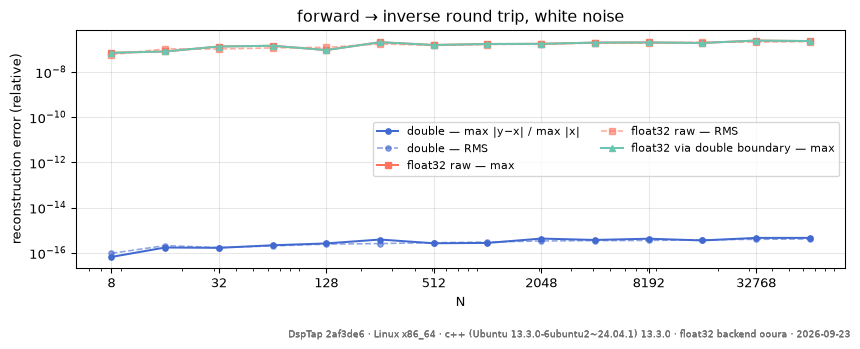

worst double round trip over all N: 4.57e-16; worst float32 raw: 2.45e-07
largest difference between the float profile's double-boundary and raw paths, any N: 0.0e+00


In [5]:
def roundtrip(N):
    x = rng.standard_normal(N)
    x32 = x.astype(np.float32)
    d = tap.RealFFT(N, "double")
    f = tap.RealFFT(N, "float")
    y_d = d.inverse(d.forward(x))
    y_fb = f.inverse(f.forward(x32.astype(np.float64)))            # float profile, double boundary
    buf = x32.copy(); f.forward_inplace_raw(buf); f.inverse_inplace_raw(buf)
    y_fr = buf * np.float32(2.0 / N)                                # float profile, raw, float32 scale
    def stats(y, ref):
        e = y.astype(np.float64) - ref.astype(np.float64)
        return np.max(np.abs(e)) / np.max(np.abs(ref)), np.linalg.norm(e) / np.linalg.norm(ref)
    return (*stats(y_d, x), *stats(y_fb, x32), *stats(y_fr, x32), np.max(np.abs(y_fb - y_fr)))

rt = np.array([(N, *roundtrip(N)) for N in SIZES])
print(f"{'N':>6} | {'double max':>10} {'double rms':>10} | {'f32/dbl max':>11} {'f32/dbl rms':>11} | {'f32 raw max':>11} {'f32 raw rms':>11}")
for r in rt:
    print(f"{int(r[0]):>6} | {r[1]:10.2e} {r[2]:10.2e} | {r[3]:11.2e} {r[4]:11.2e} | {r[5]:11.2e} {r[6]:11.2e}")

fig, ax = plt.subplots(figsize=(9, 3.6))
Ns = rt[:, 0]
ax.loglog(Ns, rt[:, 1], "o-", color=C[0], ms=4, lw=1.5, label="double — max |y−x| / max |x|")
ax.loglog(Ns, rt[:, 2], "o--", color=C[0], ms=4, lw=1.2, alpha=0.6, label="double — RMS")
ax.loglog(Ns, rt[:, 5], "s-", color=C[2], ms=4, lw=1.5, label="float32 raw — max")
ax.loglog(Ns, rt[:, 6], "s--", color=C[2], ms=4, lw=1.2, alpha=0.6, label="float32 raw — RMS")
ax.loglog(Ns, rt[:, 3], "^-", color=C[3], ms=4, lw=1.5, label="float32 via double boundary — max")
ax.set(xlabel="N", ylabel="reconstruction error (relative)", title="forward → inverse round trip, white noise",
       xticks=SIZES[::2], xticklabels=[str(s) for s in SIZES[::2]])
ax.legend(fontsize=8, ncol=2)
stamp(fig)
stamp(fig)
stamp(fig)
plt.show()
print(f"worst double round trip over all N: {rt[:, 1].max():.2e}; worst float32 raw: {rt[:, 5].max():.2e}")
print(f"largest difference between the float profile's double-boundary and raw paths, any N: {rt[:, 7].max():.1e}")

## 4 · Fixed point — Q15 and Q31 through the ABI

`basic_real_fft<std::int16_t | std::int32_t, Scaling>` (`fft/fixed_point.h`, Stage 3b) shares the
floating profiles' contract — packing, exp(+i), unnormalized inverse — and adds an **exponent**:
every transform returns e such that the double golden model's result on the same input, read as
fractions of full scale, equals the buffer × 2^e. Under `scaling::fixed` e is the constant
`fixed_scaling_exponent(N)` (log₂N for Q15, so the forward output is exactly X/N; log₂N + 1 for
Q31, X/2N, the one-bit input pre-shift that buys the missing guard bits); under
`scaling::block_floating` 0 ≤ e ≤ that constant, chosen per block from the data's headroom. No 2/N
is ever applied: a raw round trip reconstructs x = out · 2^(e_fwd + e_inv + 1 − log₂N).

The ABI (Stage 3c, `tools/capi/dsptap_capi.h`) presents this two ways, and the bridge follows it:

- `RealFFT.forward(x)` / `inverse(a)` at the **double boundary**: x is quantized to the Q format by
  the substrate's `round_sat` (half away from zero, saturating), the transform runs, and the
  native result comes back as fractions × 2^e — so the array is in the double profile's units
  and compares to `RealFFT(N, "double")` on the same quantized input directly, whatever e was;
  the exponent is `last_exponent` (or `forward_with_exponent`). The fixed-point `inverse` is the
  **unnormalized** inverse (no 2/N).
- `forward_inplace_raw` / `inverse_inplace_raw` on the **native int16/int32 buffer**, returning e:
  the profile's own arithmetic with no conversion anywhere, the path every measurement below
  uses. `to_native` / `from_native` are the boundary's quantization and reading, so the two
  paths can be checked against each other.

The cell below does that check, shows the exponents each policy chooses on a full-scale tone,
and confirms the packing contract holds for the integer profiles too (`unpack` lands on
`numpy.fft.rfft` of the quantized input, to the Q31 floor).

In [6]:
FIXED = ["q15", "q31", "q15_bfp", "q31_bfp"]
N = 512
n = np.arange(N)
x = 0.75 * np.cos(2 * np.pi * 37 * n / N + 0.4)
g = tap.RealFFT(N, "double")

print(f"{'profile':8} {'dtype':6} {'LSB':>9} {'bound':>5} {'e':>3}  {'boundary == raw path':>20}  {'max |X - G(x_q)| / LSB·2^e':>27}  {'unpack vs rfft(x_q)':>19}")
for p in FIXED:
    f = tap.RealFFT(N, p)
    X, e = f.forward_with_exponent(x)               # double boundary: quantize, transform, read back × 2^e
    raw = f.to_native(x)                            # the same quantization, on the native buffer
    e_raw = f.forward_inplace_raw(raw)
    same = e == e_raw and np.array_equal(f.from_native(raw, e_raw), X)
    xq = f.from_native(f.to_native(x))              # what the transform actually saw
    G = g.forward(xq)
    dev = np.max(np.abs(X - G)) / (2.0 ** (e - f.frac_bits))
    packing = np.max(np.abs(f.unpack(X) - np.fft.rfft(xq))) / np.max(np.abs(G))
    print(f"{p:8} {str(f.dtype):6} {2.0 ** -f.frac_bits:9.2e} {f.exponent_bound:5d} {e:3d}  {str(same):>20}  {dev:27.3f}  {packing:19.2e}")
print("\n(deviation in output LSB at the returned exponent: the kernel's rounding; packing error peak-normalized)")

# The exponent identity of a raw round trip, per policy, on the same tone.
print(f"\n{'profile':8} {'e_fwd':>5} {'e_inv':>5} {'k = e_fwd+e_inv+1-log2 N':>25}  {'max |x_q - out·2^k|: input LSB':>30} {'reconstructed LSB':>18}")
for p in FIXED:
    f = tap.RealFFT(N, p)
    buf = f.to_native(x); xq = f.from_native(buf)
    e_f = f.forward_inplace_raw(buf); e_i = f.inverse_inplace_raw(buf)
    k = e_f + e_i + 1 - int(np.log2(N))
    err = np.max(np.abs(xq - f.from_native(buf, k))) / 2.0 ** -f.frac_bits
    print(f"{p:8} {e_f:5d} {e_i:5d} {k:25d}  {err:30.3f} {err / 2.0 ** k:18.3f}")
print("(one reconstructed LSB is 2^k input LSB: the fixed schedule discards log2 N bits twice, block floating point keeps them)")

profile  dtype        LSB bound   e  boundary == raw path   max |X - G(x_q)| / LSB·2^e  unpack vs rfft(x_q)
q15      int16   3.05e-05     9   9                  True                        0.168             1.48e-05
q31      int32   4.66e-10    10  10                  True                        1.107             3.21e-09
q15_bfp  int16   3.05e-05     9   8                  True                        0.335             1.48e-05
q31_bfp  int32   4.66e-10    10  10                  True                        1.107             3.21e-09

(deviation in output LSB at the returned exponent: the kernel's rounding; packing error peak-normalized)

profile  e_fwd e_inv  k = e_fwd+e_inv+1-log2 N  max |x_q - out·2^k|: input LSB  reconstructed LSB
q15          9     9                        10                         510.000              0.498
q31         10    10                        12                        5362.000              1.309
q15_bfp      8     1                         1             

### 4.1 · Noise floor vs input level, against Welch's model and the battery's pins

The measurement is the battery's (`tests/test_fft_fixed.cpp`, `NoiseFloorTracksWelchModel`),
re-run through the ABI on the same inputs: white noise from the shared xorshift32 generator
(seed `0x2545F491 ^ N`, uniform in ±A) and an on-bin tone at bin N/8 + 3 (peak A × full scale,
phase 0.3), quantized to the profile by `round_sat`, at A = 0 / −20 / −40 / −60 dBFS and
N = 256 / 512 / 2048. The forward transform runs on the native buffer; the double golden model runs
on the *same quantized input*, so only the kernel's roundings and its twiddle quantization are in
the error; over the interior bins (2 … N−1: DC and Nyquist take the glue path) the error power per
component is the **floor** and the golden power the **signal**, both in dBFS/component at the
returned exponent, and their ratio the per-bin SNR. The floor is also given in output LSB rms, the
number the headers quote.

**The model** (Welch 1969; Oppenheim & Weinstein 1972), specialized to this kernel exactly as the
battery specializes it (`docs/fft-fixed-point.md` §5): every `shr_round` of s bits injects
(1 − 4^−s)·q²/12 per component on each of the stage's inputs, every rotation two `mul_coeff`
roundings (2·q²/12) on the 3 of 4 outputs that rotate, plus the twiddle's own ±2^−31; noise
propagates through each later radix-4 stage with power gain 4·4^−shift; the post-pass adds its
shift and rotation; the Q15 narrow adds its (2^−15)²/12. Under block floating point the per-stage
schedule is not observable from outside, so the model brackets it: the **early** schedule (the
exponent spent on the first stages) is the worst case and is what the battery pins against; the
**late** schedule is the best case. The dashed curves below are the early-schedule model.

profile  mat.      N  dBFS  e   signal    floor    model   (late)   rms LSB  ratio  SNR dB
q15      noise   256     0  8   -31.90  -101.03  -101.10  -101.10     0.291  1.017   69.12
q15      noise   256   -20  8   -51.90  -101.01  -101.10  -101.10     0.292  1.021   49.10
q15      noise   256   -40  8   -71.90  -101.61  -101.10  -101.10     0.272  0.889   29.71
q15      noise   256   -60  8   -91.91  -100.87  -101.10  -101.10     0.296  1.053    8.96
q15      noise   512     0  9   -34.58  -101.06  -101.10  -101.10     0.290  1.010   66.48
q15      noise   512   -20  9   -54.58  -100.87  -101.10  -101.10     0.296  1.055   46.29
q15      noise   512   -40  9   -74.58  -101.22  -101.10  -101.10     0.285  0.973   26.64
q15      noise   512   -60  9   -94.59  -101.12  -101.10  -101.10     0.288  0.996    6.53
q15      noise  2048     0 11   -40.91  -101.09  -101.10  -101.10     0.289  1.004   60.18
q15      noise  2048   -20 11   -60.91  -101.02  -101.10  -101.10     0.291  1.019   40.11

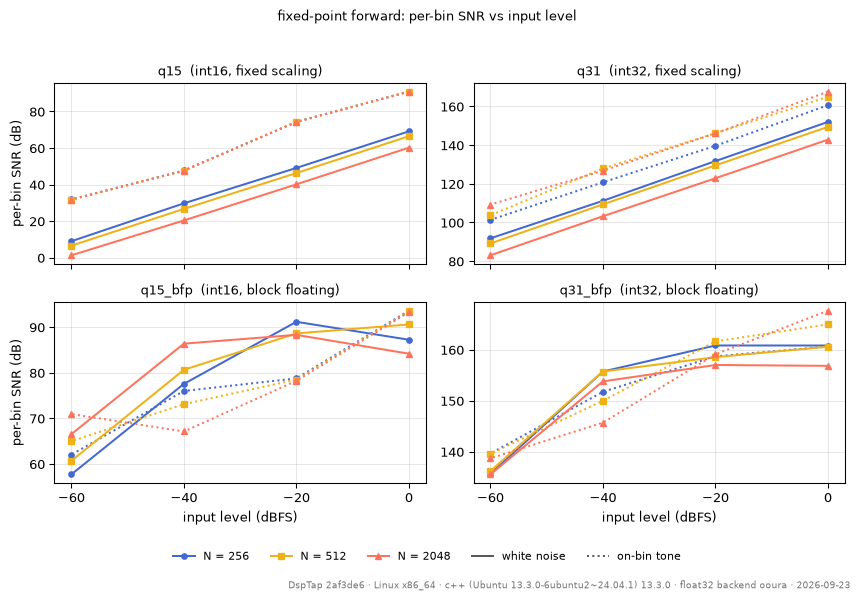

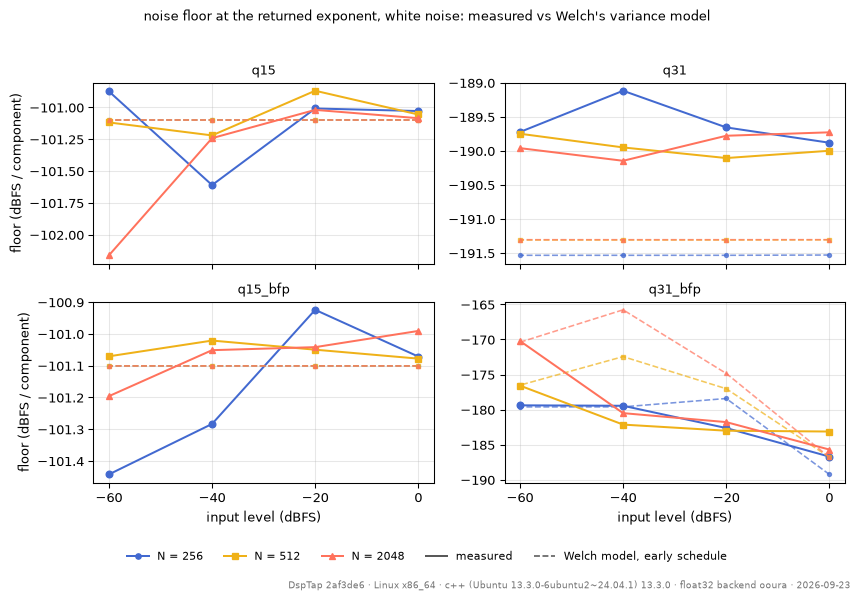

In [7]:
# --- the battery's generators, as test-vector generation (tests/support/signals.h) ---
def xorshift32_units(seed, count):
    """Marsaglia's xorshift32, uniform in [-1, 1): the same sequence the battery draws."""
    s = seed if seed != 0 else 0x9E3779B9
    out = np.empty(count)
    for i in range(count):
        s ^= (s << 13) & 0xFFFFFFFF
        s ^= s >> 17
        s ^= (s << 5) & 0xFFFFFFFF
        out[i] = s / 2147483648.0 - 1.0
    return out

def random_signal(fft, count, seed, amplitude=1.0):
    return fft.to_native(amplitude * xorshift32_units(seed, count))

def tone(fft, count, bin_, amplitude, phase=0.0):
    j = np.arange(count, dtype=np.float64)
    turns = np.fmod(bin_ * j, float(count)) / float(count)     # exact on integer bins
    return fft.to_native(amplitude * np.cos(2 * np.pi * turns + phase))

def lsb(fft):
    return 2.0 ** -fft.frac_bits

# --- Welch's model, specialized as the battery specializes it ---
def kernel_stages(count, fold_pre_shift, q15_final_shift):
    """[inputs summed per output, fixed shift, fraction of rotated outputs] per stage."""
    stages, m, span = [], count // 2, count // 2
    while span >= 4:
        stages.append([4, 2, 0.75 * (1.0 - 4.0 / span)])
        span //= 4
    if not stages or (m >> (2 * len(stages))) == 2:
        stages.append([2, 1, 0.0])                     # radix-2 final stage (log2 M odd)
    if fold_pre_shift:
        stages[0][1] += 1                              # Q31 fixed: pre-shift folded into stage 1
    stages.append([1, 1, 1.0])                         # the real post-pass
    if q15_final_shift:
        stages.append([1, 31, 0.0])                    # Q15 BFP: the shift before the narrow
    return stages

def shifts_for(stages, e, which):
    if which == "fixed":
        return [st[1] for st in stages]
    shifts, remaining = [0] * len(stages), e
    for t in (range(len(stages)) if which == "early" else range(len(stages) - 1, -1, -1)):
        if remaining <= 0:
            break
        shifts[t] = min(stages[t][1], remaining)
        remaining -= shifts[t]
    return shifts

def welch_model(stages, shifts, q_int, q_out_extra, input_variance):
    twiddle_lsb, rounding = 2.0 ** -31, q_int * q_int / 12.0
    noise, signal = 0.0, input_variance
    for st, s in zip(stages, shifts):
        gain = st[0] * 4.0 ** -s
        noise, signal = noise * gain, signal * gain
        if s > 0:
            noise += st[0] * (1.0 - 4.0 ** -s) * rounding
        if st[2] > 0.0:
            noise += st[2] * (2.0 * rounding + 2.0 * signal * twiddle_lsb ** 2 / 3.0)
    return noise + q_out_extra ** 2 / 12.0

def measure_floor(profile, count, level_db, material):
    f, gold = tap.RealFFT(count, profile), tap.RealFFT(count, "double")
    amplitude = 10 ** (level_db / 20)
    if material == "noise":
        xq, var = random_signal(f, count, 0x2545F491 ^ count, amplitude), amplitude ** 2 / 3
    else:
        a = amplitude * (1.0 - lsb(f))
        xq, var = tone(f, count, count // 8 + 3, a, 0.3), a * a / 2
    G = gold.forward(f.from_native(xq))
    buf = xq.copy()
    e = f.forward_inplace_raw(buf)
    err = f.from_native(buf)[2:] - (G * 2.0 ** -e)[2:]
    noise, signal = np.mean(err ** 2), np.mean((G * 2.0 ** -e)[2:] ** 2)
    is_q15, is_bfp = f.frac_bits == 15, f.is_block_floating
    stages = kernel_stages(count, (not is_bfp) and not is_q15, is_bfp and is_q15)
    q_int, q_out = 2.0 ** -(29 if is_q15 else 31), lsb(f) if is_q15 else 0.0
    model = welch_model(stages, shifts_for(stages, e, "early" if is_bfp else "fixed"), q_int, q_out, var)
    late = welch_model(stages, shifts_for(stages, e, "late" if is_bfp else "fixed"), q_int, q_out, var)
    db = lambda p: 10 * np.log10(max(p, 1e-300))
    return dict(profile=profile, n=count, level=level_db, material=material, e=e, signal_db=db(signal),
                floor_db=db(noise), model_db=db(model), late_db=db(late), rms_lsb=np.sqrt(noise) / lsb(f),
                ratio=noise / model, snr_db=db(signal) - db(noise))

LEVELS, NS = [0, -20, -40, -60], [256, 512, 2048]
rows = [measure_floor(p, nn, lv, mat) for p in FIXED for nn in NS for lv in LEVELS for mat in ("noise", "tone")]

print(f"{'profile':8} {'mat.':5} {'N':>5} {'dBFS':>5} {'e':>2} {'signal':>8} {'floor':>8} {'model':>8} {'(late)':>8}   {'rms LSB':>7} {'ratio':>6} {'SNR dB':>7}")
for r in rows:
    if r["material"] == "noise":
        print(f"{r['profile']:8} {r['material']:5} {r['n']:5d} {r['level']:5d} {r['e']:2d} {r['signal_db']:8.2f} {r['floor_db']:8.2f} "
              f"{r['model_db']:8.2f} {r['late_db']:8.2f}   {r['rms_lsb']:7.3f} {r['ratio']:6.3f} {r['snr_db']:7.2f}")
print("(dBFS per component at the returned exponent; the on-bin tone rows are in `rows` and in the pin table below)")

# Per-bin SNR vs input level: one panel per profile, one line per N; noise solid, tone dotted.
fig, axes = plt.subplots(2, 2, figsize=(9, 6.2), sharex=True)
markers = {256: "o", 512: "s", 2048: "^"}
for ax, p in zip(axes.flat, FIXED):
    for ci, nn in enumerate(NS):
        for mat, ls in (("noise", "-"), ("tone", ":")):
            sel = [r for r in rows if r["profile"] == p and r["n"] == nn and r["material"] == mat]
            ax.plot([r["level"] for r in sel], [r["snr_db"] for r in sel], ls, marker=markers[nn], ms=4, lw=1.5,
                    color=C[ci], label=f"N={nn} {mat}" if mat == "noise" else None)
    f = tap.RealFFT(512, p)
    ax.set_title(f"{p}  ({str(f.dtype)}, {'block floating' if f.is_block_floating else 'fixed scaling'})", fontsize=10)
    ax.set_xticks(LEVELS)
for ax in axes[1]:
    ax.set_xlabel("input level (dBFS)")
for ax in axes[:, 0]:
    ax.set_ylabel("per-bin SNR (dB)")
handles = [plt.Line2D([], [], color=C[ci], marker=markers[nn], ms=4, lw=1.5, label=f"N = {nn}") for ci, nn in enumerate(NS)]
handles += [plt.Line2D([], [], color="0.35", ls="-", lw=1.5, label="white noise"), plt.Line2D([], [], color="0.35", ls=":", lw=1.5, label="on-bin tone")]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.035))
fig.suptitle("fixed-point forward: per-bin SNR vs input level", fontsize=10)
stamp(fig, bottom=0.09)
plt.show()

# The floor itself against the model: measured (markers) vs Welch early schedule (dashed).
fig, axes = plt.subplots(2, 2, figsize=(9, 6.2), sharex=True)
for ax, p in zip(axes.flat, FIXED):
    for ci, nn in enumerate(NS):
        sel = [r for r in rows if r["profile"] == p and r["n"] == nn and r["material"] == "noise"]
        ax.plot([r["level"] for r in sel], [r["floor_db"] for r in sel], "-", marker=markers[nn], ms=5, lw=1.5, color=C[ci])
        ax.plot([r["level"] for r in sel], [r["model_db"] for r in sel], "--", marker=markers[nn], ms=3, lw=1.2,
                color=C[ci], alpha=0.7)
    ax.set_title(p, fontsize=10)
    ax.set_xticks(LEVELS)
for ax in axes[1]:
    ax.set_xlabel("input level (dBFS)")
for ax in axes[:, 0]:
    ax.set_ylabel("floor (dBFS / component)")
handles = [plt.Line2D([], [], color=C[ci], marker=markers[nn], ms=4, lw=1.5, label=f"N = {nn}") for ci, nn in enumerate(NS)]
handles += [plt.Line2D([], [], color="0.35", ls="-", lw=1.5, label="measured"), plt.Line2D([], [], color="0.35", ls="--", lw=1.2, label="Welch model, early schedule")]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 0.035))
fig.suptitle("noise floor at the returned exponent, white noise: measured vs Welch's variance model", fontsize=10)
stamp(fig, bottom=0.09)
plt.show()

Reading the two figures: under **fixed scaling** the floor is a constant of the format (Q15: the
narrow's own 0.289 LSB; Q31: ~0.7 LSB, the kernel's roundings plus the round-half-up bias the
variance model omits), so the SNR falls 20 dB per 20 dB of input level — Welch's statement. Under
**block floating point** the floor follows the block: a quiet block is not shifted (e = 0), keeps
its bits, and holds its SNR; Q31 BFP at −60 dBFS sits at the input's own 2^−31 quantization
(135 dB), where the early-schedule model is exact because there is no schedule left to bracket.
Where the measured Q31 BFP floor sits *below* the dashed early-schedule curve the kernel simply
shifted later than the worst case the pin assumes.

**Against the battery's pins.** The table below puts the battery's recorded numbers
(`docs/fft-fixed-point.md` §5, the `[ floor ]` rows measured 2026-09-18 and pinned in
`tests/test_fft_fixed.cpp`) beside what this notebook just measured through the ABI, and the
largest measured/model ratio per configuration and material beside the pinned ratio (the pin is
2× the value measured then). They must agree to the printed rounding: the kernel is integer
arithmetic over a checksum-pinned table, so a difference here would be a real finding, not noise.

In [8]:
# The battery's numbers as recorded in docs/fft-fixed-point.md §5 (2026-09-18):
#   (profile, N): (e at 0 dBFS, rms LSB at 0 dBFS, measured/model at 0 dBFS, SNR at 0 dBFS, SNR at -40 dBFS, e at -40 dBFS or None)
BATTERY = {
    ("q15", 256): (8, 0.29, 1.02, 69.1, 29.7, None),  ("q15", 512): (9, 0.29, 1.01, 66.5, 26.6, None),  ("q15", 2048): (11, 0.29, 1.00, 60.2, 20.3, None),
    ("q31", 256): (9, 0.69, 1.46, 152.0, 111.2, None), ("q31", 512): (10, 0.68, 1.35, 149.4, 109.4, None), ("q31", 2048): (12, 0.70, 1.44, 142.8, 103.2, None),
    ("q15_bfp", 256): (5, 0.29, 1.01, 87.2, 77.5, 0),  ("q15_bfp", 512): (5, 0.29, 1.01, 90.6, 80.6, 0),  ("q15_bfp", 2048): (7, 0.29, 1.03, 84.2, 86.4, 0),
    ("q31_bfp", 256): (7, 0.99, 1.79, 160.8, 155.7, 0), ("q31_bfp", 512): (7, 1.50, 2.32, 160.6, 155.7, 1), ("q31_bfp", 2048): (9, 1.12, 1.28, 156.8, 153.8, 2),
}
# The pinned ratios (2x the largest measured/model over sizes and levels): noise, tone.
PINNED_RATIO = {"q15": (2.11, 0.044), "q31": (3.49, 0.77), "q15_bfp": (2.09, 1.07), "q31_bfp": (4.65, 1.29)}

def row(p, nn, lv, mat="noise"):
    return next(r for r in rows if r["profile"] == p and r["n"] == nn and r["level"] == lv and r["material"] == mat)

worst = {}
print(f"{'profile':8} {'N':>5} | {'e0 bat/nb':>9} | {'rms bat/nb':>13} | {'ratio bat/nb':>13} | {'SNR@0 bat/nb':>15} | {'SNR@-40 bat/nb':>15} | {'e-40 bat/nb':>11}")
for p in FIXED:
    for nn in NS:
        e0, rms0, ratio0, snr0, snr40, e40 = BATTERY[(p, nn)]
        a, b = row(p, nn, 0), row(p, nn, -40)
        e40_s = f"{e40}/{b['e']}" if e40 is not None else f"-/{b['e']}"
        flag = "" if (a["e"] == e0 and abs(a["rms_lsb"] - rms0) < 0.006 and abs(a["ratio"] - ratio0) < 0.006
                      and abs(a["snr_db"] - snr0) < 0.06 and abs(b["snr_db"] - snr40) < 0.06
                      and (e40 is None or b["e"] == e40)) else "   <-- DISAGREES"
        print(f"{p:8} {nn:5d} | {e0:2d}/{a['e']:<6d} | {rms0:5.2f}/{a['rms_lsb']:<7.3f} | {ratio0:5.2f}/{a['ratio']:<7.3f} | "
              f"{snr0:6.1f}/{a['snr_db']:<8.2f} | {snr40:6.1f}/{b['snr_db']:<8.2f} | {e40_s:>11}{flag}")
    for mat in ("noise", "tone"):
        worst[(p, mat)] = max(r["ratio"] for r in rows if r["profile"] == p and r["material"] == mat)
print("\nlargest measured/model ratio over N and level (the battery pins 2x its 2026-09-18 value):")
print(f"{'profile':8} {'noise: nb':>10} {'pin':>6} {'pin/2':>6} | {'tone: nb':>9} {'pin':>6} {'pin/2':>6}")
for p in FIXED:
    pn, pt = PINNED_RATIO[p]
    print(f"{p:8} {worst[(p, 'noise')]:10.3f} {pn:6.2f} {pn / 2:6.3f} | {worst[(p, 'tone')]:9.3f} {pt:6.2f} {pt / 2:6.3f}")
disagree = [(p, nn) for p in FIXED for nn in NS
            if row(p, nn, 0)["e"] != BATTERY[(p, nn)][0] or abs(row(p, nn, 0)["snr_db"] - BATTERY[(p, nn)][3]) >= 0.06]
print("\nevery row agrees with the battery to the printed rounding" if not disagree else f"DISAGREEMENTS: {disagree}")

profile      N | e0 bat/nb |    rms bat/nb |  ratio bat/nb |    SNR@0 bat/nb |  SNR@-40 bat/nb | e-40 bat/nb
q15        256 |  8/8      |  0.29/0.291   |  1.02/1.017   |   69.1/69.12    |   29.7/29.71    |         -/8
q15        512 |  9/9      |  0.29/0.290   |  1.01/1.010   |   66.5/66.48    |   26.6/26.64    |         -/9
q15       2048 | 11/11     |  0.29/0.289   |  1.00/1.004   |   60.2/60.18    |   20.3/20.33    |        -/11
q31        256 |  9/9      |  0.69/0.688   |  1.46/1.462   |  152.0/151.96   |  111.2/111.19   |         -/9
q31        512 | 10/10     |  0.68/0.679   |  1.35/1.352   |  149.4/149.40   |  109.4/109.35   |        -/10
q31       2048 | 12/12     |  0.70/0.701   |  1.44/1.437   |  142.8/142.80   |  103.2/103.22   |        -/12
q15_bfp    256 |  5/5      |  0.29/0.290   |  1.01/1.007   |   87.2/87.23    |   77.5/77.54    |         0/0
q15_bfp    512 |  5/5      |  0.29/0.289   |  1.01/1.005   |   90.6/90.58    |   80.6/80.63    |         0/0
q15_bfp   2048 |  7

### 4.2 · The Q31 DC-path bias beyond the battery's N = 2048

`fft/fixed_point.h` records an honest limit: `shr_round` rounds half up, so every shift carries a
mean error of +2^−(s+1) LSB, and along the unrotated path (twiddle index 0 at every stage, i.e. the
DC bin and its immediate neighbours through the slowly rotating early twiddles) those biases add
coherently instead of averaging out. Under fixed scaling each later 2-bit shift quarters what has
accumulated; under block floating point a stage typically shifts one bit against a magnitude gain
of two, so the bias roughly doubles per stage instead. The battery sees it as the Q31 maxima all
sitting at index 0 or 1 (4.25 LSB fixed at N = 2048, 15.99 LSB block floating at N = 1024, in the
saturation sweep; 0.81 / 1.05 LSB mean in F(x) + F(−x)) and states that beyond N = 2048 no
committed test measures it — this notebook does, to N = 65536, on the battery's own two probes
(the finding, from the table: under fixed scaling the deviation levels off at 4.25 – 4.4 LSB past
N = 2048, each later shift quartering what came before, while under block floating point the
coherent sum at index 0 / 1 roughly doubles per octave of N, 14 LSB at N = 256 to 279 LSB at
N = 65536, in the finer LSB of the lower exponent it returns):
the inverse of a full-scale constant (the largest fixed-scaling case) and F(x) + F(−x) on the
battery's −0 dBFS white noise (a linear transform of x and −x would sum to zero; the mean of the
sum is the round-half-up bias, its maximum the coherent worst case), with the deviation at index
0 / 1 shown beside the largest deviation anywhere else in the block. Q15 is included to show it
never sees the bias (it is below the narrow's quantum).

profile       N |     inverse of full-scale constant     |    F(x) + F(-x), -0 dBFS noise, forward   
                |   e  idx 0/1 LSB  elsewhere LSB |   e  idx 0/1 LSB  elsewhere LSB mean (bias)
q15         256 |   8        0.500          0.494 |   8         0.00           0.00      0.0000
q15         512 |   9        0.500          0.495 |   9         0.00           0.00      0.0000
q15        1024 |  10        0.500          0.498 |  10         0.00           0.00      0.0000
q15        2048 |  11        0.500          0.500 |  11         0.00           0.00      0.0000
q15        4096 |  12        0.500          0.499 |  12         0.00           0.00      0.0000
q15        8192 |  13        0.500          0.499 |  13         0.00           0.00      0.0000
q15       16384 |  14        0.500          0.500 |  14         0.00           0.00      0.0000
q15       32768 |  15        0.500          0.500 |  15         0.00           1.00      0.0001
q15       65536 |  16        0.500

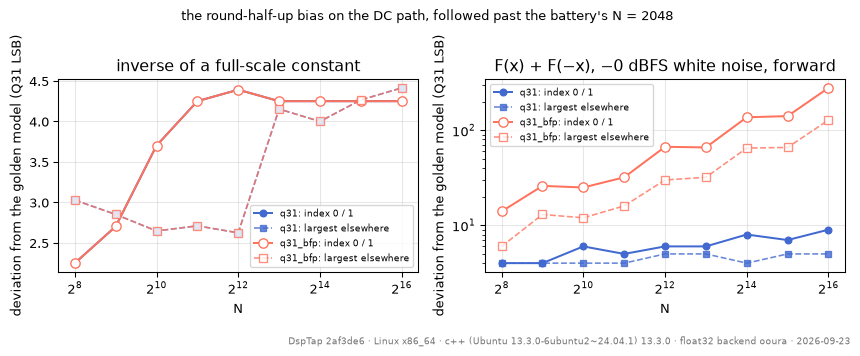

battery reference points (N <= 2048): 4.25 LSB for q31's inverse of a constant at N = 2048, index 0; F(x)+F(-x) max 6 / 62 LSB and mean 0.81 / 1.05 LSB
for q31 / q31_bfp over sizes 4 .. 2048, both directions and two levels. On the left the two curves coincide: a full-scale block has no
headroom, so block floating point follows the fixed schedule bit for bit there (the battery's BfpAtTheFullExponentIsBitIdenticalToFixed).


In [9]:
BIAS_NS = [2 ** k for k in range(8, 17)]     # 256 .. 65536

def deviation_lsb(f, out, e, golden):
    """|out - G / 2^e| in output LSB, split into the DC/Nyquist slots and the rest."""
    d = np.abs(out.astype(np.float64) - golden * 2.0 ** -(e - f.frac_bits))
    return d[:2].max(), d[2:].max()

bias = {}
for p in FIXED:
    for nn in BIAS_NS:
        f, gold = tap.RealFFT(nn, p), tap.RealFFT(nn, "double")
        info = np.iinfo(f.dtype)
        # (a) inverse of a full-scale constant spectrum (every slot at +full scale)
        const = np.full(nn, info.max, dtype=f.dtype)
        Ginv = gold.inverse(f.from_native(const)) * nn / 2          # the UNNORMALIZED double inverse
        buf = const.copy(); e = f.inverse_inplace_raw(buf)
        dc_i, rest_i = deviation_lsb(f, buf, e, Ginv)
        # (b) F(x) + F(-x): the battery's probe (RoundingBiasOnNegatedInputIsBounded), forward
        #     direction, its seed and amplitude (0.999 keeps -x representable); the mean of the
        #     sum over the block is the battery's "bias" number, the max its "max".
        xq = random_signal(f, nn, 0x9E3779B9 ^ nn, 0.999)
        a = xq.copy(); ea = f.forward_inplace_raw(a)
        b = (-xq).astype(f.dtype); eb = f.forward_inplace_raw(b)
        assert ea == eb
        s = a.astype(np.float64) + b.astype(np.float64)
        bias[(p, nn)] = (e, dc_i, rest_i, ea, np.abs(s[:2]).max(), np.abs(s[2:]).max(), s.mean())

print(f"{'profile':8} {'N':>6} | {'inverse of full-scale constant':^38} | {'F(x) + F(-x), -0 dBFS noise, forward':^42}")
print(f"{'':8} {'':>6} | {'e':>3} {'idx 0/1 LSB':>12} {'elsewhere LSB':>14} | {'e':>3} {'idx 0/1 LSB':>12} {'elsewhere LSB':>14} {'mean (bias)':>11}")
for p in FIXED:
    for nn in BIAS_NS:
        e, dci, ri, top, dcs, rs, mb = bias[(p, nn)]
        print(f"{p:8} {nn:6d} | {e:3d} {dci:12.3f} {ri:14.3f} | {top:3d} {dcs:12.2f} {rs:14.2f} {mb:11.4f}")
print("(output LSB at the returned exponent, as the battery counts them; under block floating point that exponent is below the constant, so its LSB is finer)")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (col_dc, col_rest, title, log) in zip(axes, ((1, 2, "inverse of a full-scale constant", False), (4, 5, "F(x) + F(−x), −0 dBFS white noise, forward", True))):
    for ci, p in enumerate(("q31", "q31_bfp")):
        mfc = C[2 * ci] if ci == 0 else "white"      # hollow markers for bfp: on the left panel the two coincide
        ax.plot(BIAS_NS, [bias[(p, nn)][col_dc] for nn in BIAS_NS], "-", marker="o", ms=5 + 2 * ci, lw=1.5, color=C[2 * ci],
                mfc=mfc, label=f"{p}: index 0 / 1")
        ax.plot(BIAS_NS, [max(bias[(p, nn)][col_rest], 1e-3) for nn in BIAS_NS], "--", marker="s", ms=4 + 2 * ci, lw=1.2,
                color=C[2 * ci], mfc=mfc, alpha=0.8, label=f"{p}: largest elsewhere")
    ax.set_xscale("log", base=2)
    if log:
        ax.set_yscale("log")
    ax.set(xlabel="N", ylabel="deviation from the golden model (Q31 LSB)", title=title)
    ax.legend(fontsize=7)
fig.suptitle("the round-half-up bias on the DC path, followed past the battery's N = 2048", fontsize=10)
stamp(fig)
plt.show()
print("battery reference points (N <= 2048): 4.25 LSB for q31's inverse of a constant at N = 2048, index 0; F(x)+F(-x) max 6 / 62 LSB and mean 0.81 / 1.05 LSB")
print("for q31 / q31_bfp over sizes 4 .. 2048, both directions and two levels. On the left the two curves coincide: a full-scale block has no")
print("headroom, so block floating point follows the fixed schedule bit for bit there (the battery's BfpAtTheFullExponentIsBitIdenticalToFixed).")

### 4.3 · Block-floating exponent on speech-like material

What a consumer of `scaling::block_floating` actually gets: the exponent per block, against the
block's level, on material with the dynamics of speech. The signal is synthesized here (no external
audio): a harmonic series on an f₀ contour around 120 Hz with vibrato and drift, a two-formant
spectral envelope and 1/k rolloff, shaped by raised-cosine syllable envelopes of random length and
level (−3 to −42 dBFS) with pauses between them, plus a −60 dBFS noise floor; 16 kHz, 3 s, blocked
at N = 512 without overlap. For each block: the exponent the Q15 and Q31 BFP forward transforms
return, the block's peak level, and — the point of the policy — the per-bin SNR of the block's
spectrum against the golden model, for the BFP profile beside the fixed-scaling profile of the
same width. A fixed-scaling Q15 spectrum of a −40 dBFS block has about 20 dB of per-bin SNR at
N = 512 (§4.1); the block-floating one keeps what the input's quantization allows.

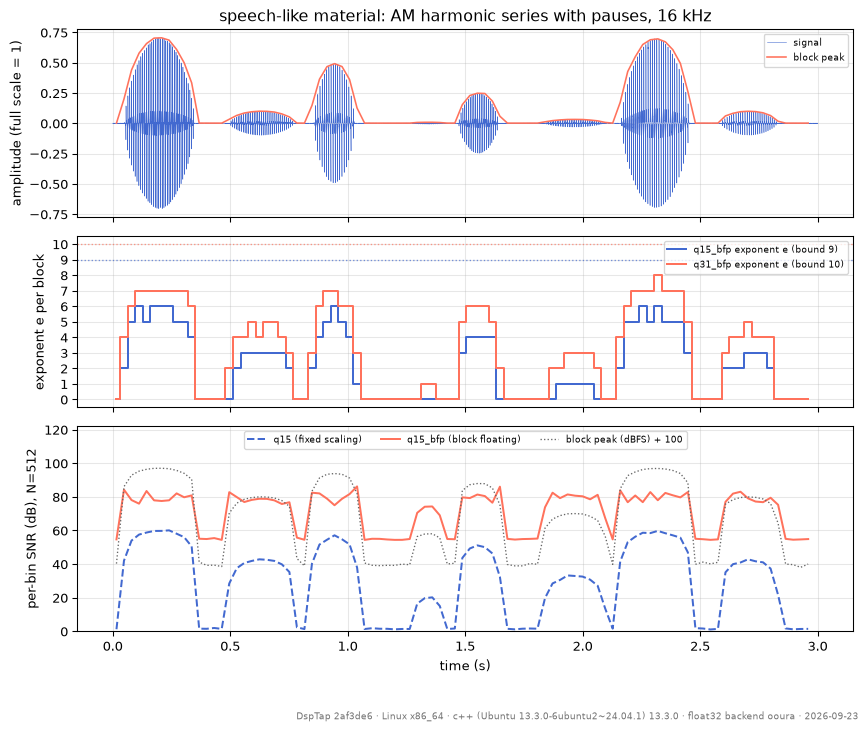

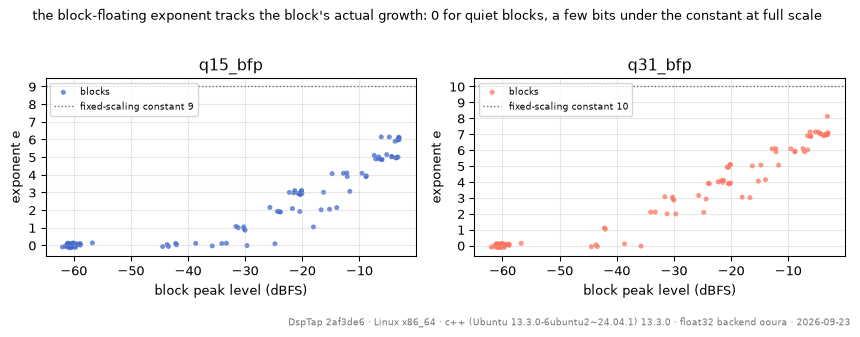

q15     : e in [9, 9] (bound 9); per-bin SNR median   35.1 dB, quiet blocks (< -30 dBFS, 44)    1.6 dB, loud blocks (> -10 dBFS, 22)   57.1 dB
q31     : e in [10, 10] (bound 10); per-bin SNR median  117.7 dB, quiet blocks (< -30 dBFS, 44)   83.7 dB, loud blocks (> -10 dBFS, 22)  139.5 dB
q15_bfp : e in [0, 6] (bound 9); per-bin SNR median   77.0 dB, quiet blocks (< -30 dBFS, 44)   55.0 dB, loud blocks (> -10 dBFS, 22)   79.3 dB
q31_bfp : e in [0, 8] (bound 10); per-bin SNR median  154.8 dB, quiet blocks (< -30 dBFS, 44)  130.6 dB, loud blocks (> -10 dBFS, 22)  155.8 dB
93 blocks; 8 syllables at levels [-3.0, -20.0, -6.0, -42.0, -12.0, -30.0, -3.0, -20.0] dBFS


In [10]:
def speech_like(fs=16000.0, seconds=3.0, seed=20260923):
    r = np.random.default_rng(seed)
    count = int(fs * seconds)
    t = np.arange(count) / fs
    env, pos, syllables = np.zeros(count), 0.05, []
    while pos < seconds - 0.2:
        dur, gap = r.uniform(0.12, 0.3), r.uniform(0.04, 0.25)
        lvl = [-3.0, -20.0, -6.0, -42.0, -12.0, -30.0][len(syllables) % 6]    # every level, in a fixed order
        i0, i1 = int(pos * fs), min(int((pos + dur) * fs), count)
        env[i0:i1] = np.maximum(env[i0:i1], 10 ** (lvl / 20) * np.sin(np.pi * np.arange(i1 - i0) / (i1 - i0)) ** 0.6)
        syllables.append((pos, dur, lvl))
        pos += dur + gap
    f0 = 120.0 * (1 + 0.15 * np.sin(2 * np.pi * 0.7 * t) + 0.02 * np.sin(2 * np.pi * 5.5 * t))
    phase = 2 * np.pi * np.cumsum(f0) / fs
    x = np.zeros(count)
    for k in range(1, 40):
        fk = k * f0
        formant = np.exp(-0.5 * ((fk - 600) / 200) ** 2) + 0.5 * np.exp(-0.5 * ((fk - 1800) / 350) ** 2) + 0.15
        x += (formant / k) * np.sin(k * phase) * (fk < 0.45 * fs)
    x = x / np.max(np.abs(x)) * env
    return x + 10 ** (-60 / 20) * r.standard_normal(count) * (0.3 + env), fs, syllables

x, fs, syllables = speech_like()
NB = 512
blocks = x[: len(x) // NB * NB].reshape(-1, NB)
tb = (np.arange(blocks.shape[0]) + 0.5) * NB / fs
peak_db = 20 * np.log10(np.maximum(np.max(np.abs(blocks), axis=1), 1e-9))

def per_block(profile):
    f, gold = tap.RealFFT(NB, profile), tap.RealFFT(NB, "double")
    es, snrs = [], []
    for b in blocks:
        buf = f.to_native(b)
        G = gold.forward(f.from_native(buf))
        e = f.forward_inplace_raw(buf)
        out = f.from_native(buf, e)
        err = np.sum((out[2:] - G[2:]) ** 2)
        es.append(e)
        snrs.append(10 * np.log10(np.sum(G[2:] ** 2) / max(err, 1e-300)))
    return np.array(es), np.array(snrs), f.exponent_bound

res = {p: per_block(p) for p in FIXED}

fig, axes = plt.subplots(3, 1, figsize=(9, 7.6), sharex=True, gridspec_kw={"height_ratios": [1.1, 1, 1.2]})
axes[0].plot(np.arange(len(x)) / fs, x, lw=0.4, color=C[0], label="signal")
axes[0].plot(tb, 10 ** (peak_db / 20), "-", lw=1.2, color=C[2], label="block peak")
axes[0].set(ylabel="amplitude (full scale = 1)", title="speech-like material: AM harmonic series with pauses, 16 kHz")
axes[0].legend(fontsize=7, loc="upper right")
for ci, p in enumerate(("q15_bfp", "q31_bfp")):
    es, _, bound = res[p]
    axes[1].step(tb, es, where="mid", lw=1.5, color=C[2 * ci], label=f"{p} exponent e (bound {bound})")
    axes[1].axhline(bound, ls=":", lw=1, color=C[2 * ci], alpha=0.7)
axes[1].set(ylabel="exponent e per block", yticks=range(0, 11))
axes[1].legend(fontsize=7, loc="upper right")
for ci, (p, ls) in enumerate((("q15", "--"), ("q15_bfp", "-"))):
    axes[2].plot(tb, res[p][1], ls, lw=1.5, color=C[ci * 2], label=f"{p} ({'block floating' if 'bfp' in p else 'fixed scaling'})")
axes[2].plot(tb, peak_db + 100, ":", lw=1, color="0.4", label="block peak (dBFS) + 100")
axes[2].set(xlabel="time (s)", ylabel="per-bin SNR (dB), N=512", ylim=(0, 122))
axes[2].legend(fontsize=7, loc="upper center", ncol=3)
stamp(fig)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=False)
for ax, p, ci in zip(axes, ("q15_bfp", "q31_bfp"), (0, 1)):
    es, snrs, bound = res[p]
    jitter = np.random.default_rng(1).uniform(-0.15, 0.15, es.size)
    ax.scatter(peak_db, es + jitter, s=14, color=C[2 * ci], alpha=0.75, edgecolor="none", label="blocks")
    ax.axhline(bound, ls=":", lw=1, color="0.4", label=f"fixed-scaling constant {bound}")
    ax.set(xlabel="block peak level (dBFS)", ylabel="exponent e", title=p, yticks=range(0, bound + 1))
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("the block-floating exponent tracks the block's actual growth: 0 for quiet blocks, a few bits under the constant at full scale", fontsize=9.5)
stamp(fig)
plt.show()

for p in FIXED:
    es, snrs, bound = res[p]
    quiet, loud = peak_db < -30, peak_db > -10
    print(f"{p:8}: e in [{es.min()}, {es.max()}] (bound {bound}); per-bin SNR median {np.median(snrs):6.1f} dB, "
          f"quiet blocks (< -30 dBFS, {quiet.sum():2d}) {np.median(snrs[quiet]):6.1f} dB, loud blocks (> -10 dBFS, {loud.sum():2d}) {np.median(snrs[loud]):6.1f} dB")
print(f"{blocks.shape[0]} blocks; {len(syllables)} syllables at levels {[float(l) for _, _, l in syllables]} dBFS")

### 4.4 · Fixed-point round trip

The floating profiles' round trip is §3. For the fixed-point profiles the raw round trip
`forward_inplace_raw → inverse_inplace_raw` reconstructs x = out · 2^(e_fwd + e_inv + 1 − log₂N):
under fixed scaling the two exponents are both the constant, so the result comes back at 2^−(log₂N
− 1) of full scale and log₂N − 1 bits of the input are gone twice over (the policy is for
magnitude consumers, not resynthesis); under block floating point the inverse shifts only as the
data grows, and a quiet block is reconstructed to the input's own quantization. Measured below on
the battery's white noise at 0 and −40 dBFS, N = 256 … 65536, as the reconstruction error in
*reconstructed* LSB (the battery's unit: it measured 0.56 / 3.38 / 5.0 / 41.5 for Q15 fixed /
Q31 fixed / Q15 BFP / Q31 BFP at N ≤ 2048 and pins 2×, the Q31 BFP maximum at the DC index of
§4.2) and in *input* LSB, which is the resynthesis story. The Q31 BFP worst case grows with N
past the battery's range, at the DC index, for the reason §4.2 gives.

max |x_q - out·2^k| in RECONSTRUCTED LSB (the battery's unit; k = e_fwd + e_inv + 1 - log2 N):
profile   dBFS |      256      512     1024     2048     4096     8192    16384    32768    65536
q15          0 |     0.50     0.51     0.50     0.50     0.50     0.50     0.50     0.50     0.25
q15        -40 |     0.50     0.32     0.16     0.08     0.04     0.02     0.01     0.01     0.00
q31          0 |     2.51     3.09     2.97     3.56     3.67     4.17     4.41     4.10     5.04
q31        -40 |     2.48     3.05     3.25     3.27     3.96     3.33     4.38     4.26     4.56
q15_bfp      0 |     1.50     1.00     1.50     2.00     1.50     2.50     1.50     3.00     2.00
q15_bfp    -40 |     5.00     4.00     2.00     1.00     3.00     1.00     2.00     1.00     2.00
q31_bfp      0 |    20.75    20.88    44.12    47.62    92.75   185.88   183.12   381.75   376.75
q31_bfp    -40 |    17.00    36.00    77.00    45.00   160.00    90.00   187.00   188.00   377.00

the same in INPUT LSB 

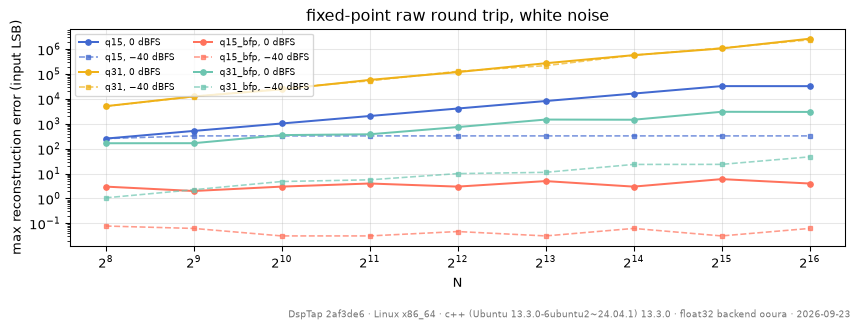

In [11]:
RT_NS = [2 ** k for k in range(8, 17)]
rt, rt_rec = {}, {}
for p in FIXED:
    for lv in (0, -40):
        vals, recs = [], []
        for nn in RT_NS:
            f = tap.RealFFT(nn, p)
            xq = random_signal(f, nn, 0x2545F491 ^ nn, 10 ** (lv / 20))
            buf = xq.copy()
            k = f.forward_inplace_raw(buf) + f.inverse_inplace_raw(buf) + 1 - int(np.log2(nn))
            err = np.max(np.abs(f.from_native(xq) - f.from_native(buf, k))) / lsb(f)
            vals.append(err)
            recs.append(err / 2.0 ** k)
        rt[(p, lv)], rt_rec[(p, lv)] = vals, recs
print("max |x_q - out·2^k| in RECONSTRUCTED LSB (the battery's unit; k = e_fwd + e_inv + 1 - log2 N):")
print(f"{'profile':8} {'dBFS':>5} | " + " ".join(f"{nn:>8}" for nn in RT_NS))
for key in rt_rec:
    print(f"{key[0]:8} {key[1]:5d} | " + " ".join(f"{v:8.2f}" for v in rt_rec[key]))
print("\nthe same in INPUT LSB (one reconstructed LSB is 2^k input LSB):")
print(f"{'profile':8} {'dBFS':>5} | " + " ".join(f"{nn:>8}" for nn in RT_NS))
for key in rt:
    print(f"{key[0]:8} {key[1]:5d} | " + " ".join(f"{v:8.1f}" for v in rt[key]))
print("(a -40 dBFS white-noise block peaks at 328 Q15 LSB: the fixed Q15 round trip returns nothing of it, and the error is the signal itself)")
# Where the Q31 block-floating maximum sits: the DC path, as in §4.2.
where = []
for nn in RT_NS:
    f = tap.RealFFT(nn, "q31_bfp")
    xq = random_signal(f, nn, 0x2545F491 ^ nn, 1.0)
    buf = xq.copy()
    k = f.forward_inplace_raw(buf) + f.inverse_inplace_raw(buf) + 1 - int(np.log2(nn))
    where.append(int(np.argmax(np.abs(f.from_native(xq) - f.from_native(buf, k)))))
print(f"index of the q31_bfp 0 dBFS maximum per N: {where}  (0 = DC, 1 = Nyquist)")

fig, ax = plt.subplots(figsize=(9, 3.4))
for ci, p in enumerate(FIXED):
    ax.loglog(RT_NS, np.maximum(rt[(p, 0)], 1e-2), "-", marker="o", ms=4, lw=1.5, color=C[ci], label=f"{p}, 0 dBFS")
    ax.loglog(RT_NS, np.maximum(rt[(p, -40)], 1e-2), "--", marker="s", ms=3, lw=1.2, color=C[ci], alpha=0.7, label=f"{p}, −40 dBFS")
ax.set_xscale("log", base=2)
ax.set(xlabel="N", ylabel="max reconstruction error (input LSB)", title="fixed-point raw round trip, white noise")
ax.legend(fontsize=7, ncol=2, loc="upper left")
stamp(fig)
plt.show()

### 4.5 · Host identity: the battery's output fingerprints, through the ABI

The fixed-point transform is integer arithmetic over a checksum-pinned table, so for a fixed
input its output is one exact bit pattern on every host, and the battery pins that pattern
(`OutputFingerprintIsPinned`: FNV-1a-64 over the output block's bit patterns and the exponent, for
the shared xorshift32 noise at seed `0x2545F491 ^ N`, forward and inverse, N = 512 and 2048, all
four configurations). The same hash over the same inputs through `forward_inplace_raw` /
`inverse_inplace_raw` must reproduce the sixteen constants pinned on 2026-09-22 — which shows at
once that the ABI's raw path adds no conversion, that the bridge's `to_native` is the battery's
quantization, and that this host is one of the hosts the pins describe.

In [12]:
PINNED_FINGERPRINTS = {   # tests/test_fft_fixed.cpp k_fingerprints: forward_512, inverse_512, forward_2048, inverse_2048
    "q15":     (0x4f175f4249270f31, 0x0f3c8b2a39ec223b, 0xaa3d6d7935f2236e, 0xd8fff1abc5ade94a),
    "q31":     (0x2b68021a254d5404, 0xd566c7d6240f5833, 0x78836f72717d5823, 0x1bf3a2198038ef4c),
    "q15_bfp": (0x25e5ec565482430e, 0x8347e29c2a96a280, 0x056ef3dccd411b3a, 0xd3a7cfeef3f95a75),
    "q31_bfp": (0xced316f629630991, 0xf9887376e9bfa8a5, 0x510fe44ccd740698, 0xe12bab5c64d06041),
}

def fnv1a64(out, e):
    """FNV-1a-64 over each sample's unsigned bit pattern, least significant byte first, then the
    exponent as four bytes: the battery's output_fingerprint."""
    h, width = 0xcbf29ce484222325, out.dtype.itemsize
    words = (out.astype(np.int64) & ((1 << (8 * width)) - 1)).tolist() + [e & 0xFFFFFFFF]
    widths = [width] * out.size + [4]
    for v, w in zip(words, widths):
        for b in range(w):
            h = ((h ^ ((v >> (8 * b)) & 0xff)) * 0x100000001b3) & 0xFFFFFFFFFFFFFFFF
    return h

all_ok = True
print(f"{'profile':8} {'N':>5} {'dir':>7} {'e':>3}  {'this host, via the ABI':>22}  {'pinned':>18}  match")
for p, pins in PINNED_FINGERPRINTS.items():
    for nn, pf, pi in ((512, pins[0], pins[1]), (2048, pins[2], pins[3])):
        f = tap.RealFFT(nn, p)
        xq = random_signal(f, nn, 0x2545F491 ^ nn, 1.0)
        for direction, pin in (("forward", pf), ("inverse", pi)):
            buf = xq.copy()
            e = f.forward_inplace_raw(buf) if direction == "forward" else f.inverse_inplace_raw(buf)
            h = fnv1a64(buf, e)
            all_ok &= h == pin
            print(f"{p:8} {nn:5d} {direction:>7} {e:3d}  {h:022x}  {pin:018x}  {'yes' if h == pin else 'NO'}")
print("\nall sixteen fingerprints reproduce the battery's pins" if all_ok else "\nFINGERPRINT MISMATCH: a finding to record per host, never to smooth over")

profile      N     dir   e  this host, via the ABI              pinned  match
q15        512 forward   9  0000004f175f4249270f31  004f175f4249270f31  yes
q15        512 inverse   9  0000000f3c8b2a39ec223b  000f3c8b2a39ec223b  yes
q15       2048 forward  11  000000aa3d6d7935f2236e  00aa3d6d7935f2236e  yes
q15       2048 inverse  11  000000d8fff1abc5ade94a  00d8fff1abc5ade94a  yes
q31        512 forward  10  0000002b68021a254d5404  002b68021a254d5404  yes
q31        512 inverse  10  000000d566c7d6240f5833  00d566c7d6240f5833  yes
q31       2048 forward  12  00000078836f72717d5823  0078836f72717d5823  yes
q31       2048 inverse  12  0000001bf3a2198038ef4c  001bf3a2198038ef4c  yes
q15_bfp    512 forward   5  00000025e5ec565482430e  0025e5ec565482430e  yes
q15_bfp    512 inverse   5  0000008347e29c2a96a280  008347e29c2a96a280  yes
q15_bfp   2048 forward   7  000000056ef3dccd411b3a  00056ef3dccd411b3a  yes
q15_bfp   2048 inverse   7  000000d3a7cfeef3f95a75  00d3a7cfeef3f95a75  yes
q31_bfp   

## 5 · Backend comparison — Ooura vs vDSP / CMSIS-Helium (Stage 4 placeholder)

**No data yet, by construction.** One capi binary carries one float32 engine — Ooura, or the
platform backend the build selected — so this notebook can only ever measure the engine the
setup cell names, and a same-binary comparison is impossible until Stage 4 makes the engine an
explicit parameter of `basic_real_fft` with an ABI tag (`docs/audit-fft-and-code-smells.md`,
Stage 4; Part 8 item 6 asks for "the backend comparison on the host that runs it"). When that
lands the capi gains an engine selector (an additive create variant and a per-handle backend
query) and this section fills with, on the host that executed the notebook:

- **Per-bin agreement between engines** on broadband material and on on-bin tones, both as
  peak-normalized error (the parity metric of `tests/test_fft_backend.cpp`) and as the
  empty-bin per-bin ratio of §2b, so the vDSP alignment finding recorded in `fft.h` is visible
  as a curve and not only as a comment;
- **Each engine against the double golden model**, the §2 sweep repeated per engine, since
  "agrees with Ooura" and "accurate" are different claims (`fft.h` records that on empty bins
  Ooura is not the accurate one);
- **Round trip per engine**, the §3 sweep, including the unnormalized-inverse scale each backend
  wrapper applies to land on Ooura's contract.

The fixed-point profiles are outside this question: they run the portable int32 kernel on every
host, and §4.5 is their host-identity statement. Until Stage 4 the honest statement for float32 is
the setup cell's: one backend, named, measured.

## Summary

- **Packing and sign** (§1): `fft.h`'s packed layout and exp(+i) convention hold exactly as
  documented; `RealFFT.unpack` (which conjugates) matches `numpy.fft.rfft` to double rounding
  (2.7e-15 at N = 64), and the raw imaginary parts are the mirror image of numpy's.
- **Float vs double** (§2): on white noise the float32 profile's RMS relative error against the
  golden model runs from 5.4e-8 at N = 8 to 1.5e-7 at N = 65536, growing as (log₂N)^0.6 — close
  to Weinstein's √log₂N and an order of magnitude under the ε₃₂·log₂N worst-case bound; the
  median per-bin error is the same size, the 95th percentile ~4x it. On numerically empty bins
  the per-bin relative error is meaningless (§2b: median ~1 against the exact-signal reference,
  and at bin 3 half the bins exceed 1e6), exactly as the header says; peak-normalized error
  there is 6e-8 to 1.2e-7.
- **Round trip** (§3): `inverse(forward(x))` reproduces the input to at most 4.6e-16 in double
  and 2.5e-7 in float32 (relative to the block's peak) over N = 8 … 65536; the float profile's
  double-boundary path is bit-identical to its raw path.
- **Fixed point** (§4): the ABI's double boundary and raw path agree bit for bit, and the
  exponent contract holds as `fft.h` states it (§4.0). The noise-floor table re-measured through
  the ABI agrees with the battery's pinned rows to the printed rounding (§4.1): Q15 fixed 0.29 LSB
  rms at every N and level (69.1 / 66.5 / 60.2 dB per-bin SNR at 0 dBFS, N = 256 / 512 / 2048),
  Q31 fixed 0.67 – 0.75 LSB (152.0 / 149.4 / 142.8 dB), block floating point 84 – 91 dB (Q15) and
  157 – 161 dB (Q31) at 0 dBFS and 78 – 86 / 154 – 156 dB at −40 dBFS; the largest
  measured/model ratios sit at exactly half the pins. Past N = 2048 the Q31 DC-path bias levels
  off under fixed scaling (4.25 – 4.4 LSB on the inverse of a full-scale constant) and keeps
  roughly doubling per octave under block floating point (F(x) + F(−x) at index 0 / 1: 14 LSB at
  N = 256, 279 LSB at N = 65536; the BFP raw round trip's worst reconstructed LSB grows the same
  way, 21 to 377), as the header's honest-limit note predicts (§4.2, §4.4). On speech-like
  material the BFP exponent is 0 for blocks below about −35 dBFS and 2 – 3 bits under the
  constant at full scale,
  and the block-floating Q15 spectrum holds its per-bin SNR through the quiet syllables where
  fixed scaling's falls with the level (§4.3). The raw round trip follows the exponent identity
  (§4.4), and all sixteen pinned output fingerprints reproduce through the ABI on this host (§4.5).
- **Backend comparison** (§5): impossible in one binary until Stage 4; designed, not measured.

Every number above is produced by the shipping C++ through `tools/capi`, on the host, tree and
float32 backend the setup cell prints; the corresponding hard gates live in `tests/test_fft.cpp`,
`tests/test_fft_fixed.cpp` and `tests/test_fft_backend.cpp`, and the exact values are in the
output cells above.